# Lab 21 — LoRA / QLoRA Fine-tuning · **T4 / Free Colab Edition**

**AICB-P2T3 · Ngày 21 · Chương 5 — Fine-tuning & An Toàn**

Mục tiêu: fine-tune **Qwen2.5-1.5B** với LoRA/QLoRA trên một custom Python Coding dataset, sau đó so sánh các rank khác nhau (`r=8`, `r=16`, `r=64`).

---

## ⚙️ Profile: `T4`

| Setting | Giá trị |
|---|---|
| Model | `unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit` |
| Recommended GPU | T4 (16 GB) |
| Train batch / eval batch | 1 / 1 |
| Gradient accumulation | 8 (effective batch = 8) |
| Eval strategy | "no" |
| Max seq length cap | 512 |
| Dataset samples | 100 |
| Estimated time | ~15 phút trên T4 |

> ⚠️ **T4-specific tweaks**: dùng model siêu nhỏ 1.5B, tắt eval-during-training, batch size = 4, target ALL layers + DoRA, manual eval fallback.

## Lab Roadmap (≈ 2 giờ)

| # | Bước | Output |
|---|------|--------|
| 1 | Dataset preparation (Alpaca format, p95 tokenization, 90/10 split) | `train_ds`, `eval_ds` |
| 2 | Configure PEFT + load model 4-bit | model wrapped với LoRA |
| 3 | Train baseline `r=16` với SFTTrainer | adapter checkpoint |
| 4 | Rank experiment — train `r=8` và `r=64` | 2 adapter checkpoints |
| 5 | Evaluate (perplexity + qualitative) | so sánh metrics |
| 6 | Save + viết report | deliverable |

## Deliverable

1. **3 LoRA adapter checkpoints** (`r=8, r=16, r=64`)
2. **Evaluation report** chứa training time, peak VRAM, eval perplexity, 5 qualitative before/after examples, training cost, kết luận về rank trade-off


## 0. Setup & Environment Check

In [1]:
# Verify GPU is available before installing anything
!nvidia-smi

Thu Jun 25 05:25:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
assert torch.cuda.is_available(), "❌ GPU runtime cần được bật. Runtime > Change runtime type > GPU"
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✓ GPU: {name}")
print(f"✓ VRAM: {vram_gb:.1f} GB")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")

if vram_gb > 20:
    print("\n⚠️  Bạn có GPU lớn (>20GB VRAM). Nên dùng phiên bản BigGPU thay vì T4 này — sẽ nhanh hơn nhiều!")
elif 'T4' not in name:
    print(f"\n💡 Notebook này tối ưu cho T4 (16GB). GPU của bạn ({name}) có thể chạy được nhưng underutilized.")

✓ GPU: Tesla T4
✓ VRAM: 15.6 GB
✓ CUDA: 12.8
✓ PyTorch: 2.11.0+cu128


In [3]:
# Install Unsloth, TRL, datasets, evaluation libs
# trl >= 0.12 — accepts processing_class (matches transformers >= 4.46)
%%capture
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas

In [4]:
# Bắt buộc mount Google Drive để lưu model và kết quả không bị mất khi Colab sập
MOUNT_DRIVE = True

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/lab21_lora_t4_smollm2/results'
else:
    OUTPUT_DIR = '/content/lab21_lora_t4/results'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output dir: {OUTPUT_DIR}")

Mounted at /content/drive
✓ Output dir: /content/drive/MyDrive/lab21_lora_t4_smollm2/results


## 1. Dataset Preparation

Mục tiêu: chuẩn bị 100–500 examples Alpaca format. Có 2 lựa chọn:

**A. Dùng dataset có sẵn** — load Python instruction dataset từ HuggingFace (Bonus).  
**B. Dùng dataset của bạn** — uncomment cell B và paste data.


In [5]:
# Option A: Vietnamese Alpaca dataset (Commented out)
# from datasets import load_dataset
# raw = load_dataset('5CD-AI/Vietnamese-alpaca-gpt4-gg-translated', split='train')
# raw = raw.shuffle(seed=42).select(range(200))
# print(f'Loaded samples')


In [6]:
# Option B: Custom data with python coding (Bonus)
from datasets import load_dataset
raw = load_dataset('iamtarun/python_code_instructions_18k_alpaca', split='train')
raw = raw.shuffle(seed=42).select(range(200))
print(f'Loaded samples')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/905 [00:00<?, ?B/s]

data/train-00000-of-00001-8b6e212f3e1ece(…):   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18612 [00:00<?, ? examples/s]

Loaded samples


In [7]:
# Auto-detect column names — dataset 5CD-AI uses _vi suffix
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output trong: {cols}"
print(f"✓ Cột dùng: instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    inp = example.get(INPUT_COL, "") if INPUT_COL else ""
    inp = inp or ""
    if inp.strip():
        text = ALPACA_TEMPLATE.format(
            instruction=example[INSTRUCTION_COL], input=inp,
            output=example[OUTPUT_COL])
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(
            instruction=example[INSTRUCTION_COL],
            output=example[OUTPUT_COL])
    return {"text": text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print("\n--- Formatted sample ---")
print(ds[0]["text"][:500])

✓ Cột dùng: instruction='instruction', input='input', output='output'


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


--- Formatted sample ---
### Instruction:
Create a for loop in Python that prints the output of a multiplication table for numbers from 1 to 10.

### Input:
-

### Response:
for i in range(1, 11):
  for j in range(1, 11):
    print(i * j, end='\t')
  print()


config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.36k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Token length distribution:
  min=30, max=3033
  p50=101, p95=305, p99=752

✓ Chọn max_seq_length = 512 (cap = 512)


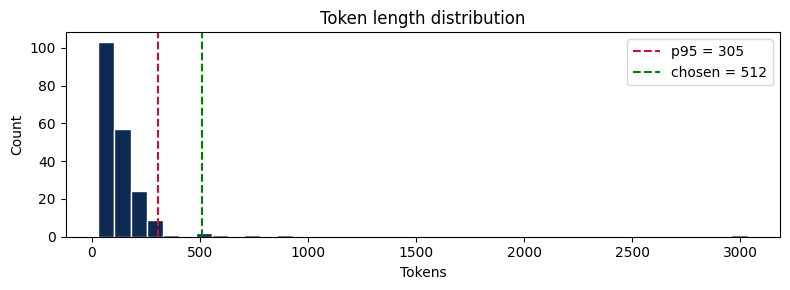

In [8]:
# Token length analysis → set max_seq_length = p95
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"
MAX_SEQ_CAP = 512  # hard cap cho profile T4

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tok.encode(x["text"])) for x in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

print(f"Token length distribution:")
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")

# Round up to power of 2, capped at MAX_SEQ_CAP
MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())
print(f"\n✓ Chọn max_seq_length = {MAX_SEQ_LENGTH} (cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='#0E2A52', edgecolor='white')
plt.axvline(p95, color='#C8102E', linestyle='--', label=f'p95 = {p95}')
plt.axvline(MAX_SEQ_LENGTH, color='green', linestyle='--', label=f'chosen = {MAX_SEQ_LENGTH}')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.title('Token length distribution')
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# 90/10 train/eval split
split = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
eval_ds = split["test"]
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")

✓ Train: 180  |  Eval: 20


## 2. Load Model + Configure LoRA (Baseline r=16)

Load **Qwen2.5-1.5B** 4-bit (NF4).

PEFT config:
- r=16 (rank — baseline)
- target_modules=ALL Layers (Bonus)
- use_dora=False (Tắt DoRA để tránh OOM)


In [10]:
from unsloth import FastLanguageModel

def load_base_model():
    """Reload base model — gọi mỗi lần train với rank khác để start từ scratch."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,            # auto: bf16 trên Ampere+, fp16 trên T4
        load_in_4bit=True,     # QLoRA
    )
    return model, tokenizer

def wrap_with_lora(model, r, alpha):
    """Wrap model với LoRA adapter."""
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        use_dora=False,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",  # -60% VRAM
        random_state=42,
    )

# Load base + wrap với r=16 baseline
base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n✓ Trainable: {trainable:,} ({100*trainable/total:.3f}% of {total:,})")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Unsloth: pad_token was a vision token (<|vision_pad|>) on a text-only model. Replaced with <|endoftext|> to avoid NaN losses.
Unsloth 2026.6.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.



✓ Trainable: 18,464,768 (2.036% of 907,081,216)


## 3. Train Baseline (`r=16`) với TRL SFTTrainer

- 3 epochs, cosine LR schedule, packing=False
- Train batch = 1, grad_accum = 8 (effective batch = 8)
- Eval strategy: "no"  # T4 không đủ VRAM cho mid-train eval


In [11]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, time, trl, transformers

print(f"trl: {trl.__version__}  |  transformers: {transformers.__version__}")

# ── Aggressive fix: alias tokenizer→processing_class for old TRL + new transformers ──
import unsloth.models._utils as _u_utils
_underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
if not getattr(_underlying_init, "_aliased", False):
    def _aliased_trainer_init(self, *args, **kwargs):
        if "tokenizer" in kwargs and "processing_class" not in kwargs:
            kwargs["processing_class"] = kwargs.pop("tokenizer")
        return _underlying_init(self, *args, **kwargs)
    _aliased_trainer_init._aliased = True
    _u_utils._original_trainer_init = _aliased_trainer_init
    if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
        _orig_t = Trainer.__init__
        def _t_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _orig_t(self, *args, **kwargs)
        _t_init._aliased = True
        Trainer.__init__ = _t_init
    print("✓ Trainer.__init__ patched")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
_SFT_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD_KWARGS = "dataset_text_field" in _SFT_PARAMS

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    base_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=8,
        warmup_ratio=0.10,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        eval_steps=25,
        save_strategy="epoch",
        optim="adamw_8bit",
        weight_decay=0.01,
        seed=42,
        report_to="none",
    )
    base_kwargs[_EVAL_KEY] = "no"  # T4 không đủ VRAM cho mid-train eval
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_extra = dict(dataset_text_field="text", packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model, "train_dataset": train_ds, "eval_dataset": eval_ds, "args": args,
    }
    if "processing_class" in _SFT_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if _SUPPORTS_OLD_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    """Robust eval — handles NotebookProgressCallback bug + OOM."""
    import gc as _gc
    _gc.collect(); torch.cuda.empty_cache()

    # Remove buggy notebook callback that breaks evaluate-after-train
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    # Try standard evaluate first
    try:
        return trainer.evaluate()["eval_loss"]
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"⚠ trainer.evaluate() failed ({type(e).__name__}). Falling back to manual eval...")

    # Manual eval loop — bulletproof
    _gc.collect(); torch.cuda.empty_cache()
    m = trainer.model
    m.eval()
    eval_dl = trainer.get_eval_dataloader()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in eval_dl:
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, "to")}
            out = m(**batch)
            total += out.loss.item(); n += 1
            del out; torch.cuda.empty_cache()
    return total / max(n, 1)

trl: 0.15.2  |  transformers: 5.5.0
✓ Trainer.__init__ patched


In [12]:
# Train baseline r=16
import gc
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0 = time.time()
result_16 = trainer_16.train()
wall_16 = time.time() - t0
vram_16 = torch.cuda.max_memory_allocated() / 1e9

print(f"\n✓ r=16 done in {wall_16/60:.1f} min, peak VRAM = {vram_16:.1f} GB")
trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))

# Compute eval — guarded so eval_loss_16/ppl_16 are always defined
try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16 = float(np.exp(eval_loss_16))
    print(f"✓ r=16 eval loss = {eval_loss_16:.4f}, perplexity = {ppl_16:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN — recover later by reloading adapter.")
    eval_loss_16 = float("nan")
    ppl_16 = float("nan")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/180 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/20 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


...

Step,Training Loss
5,0.927631
10,0.768867
15,0.734879
20,0.700365
25,0.770883
30,0.639764
35,0.596309
40,0.653759
45,0.549637
50,0.507056


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r16/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r16/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r16/checkpoint-69/tokenizer_config.json.



✓ r=16 done in 3.5 min, peak VRAM = 3.1 GB


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r16/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.mod

✓ r=16 eval loss = 0.7186, perplexity = 2.05


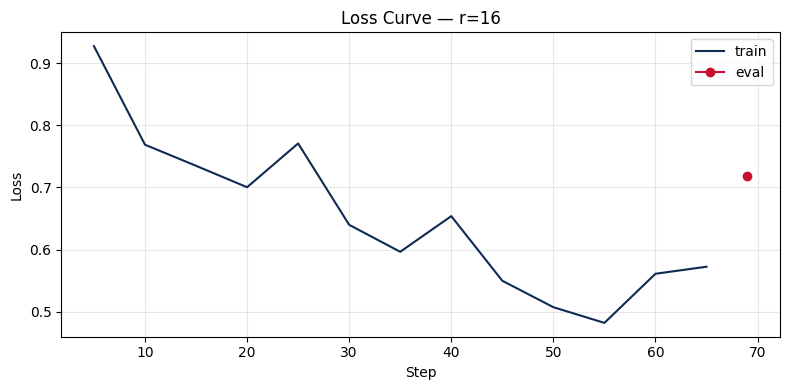


📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.


In [13]:
# Plot training loss để detect overfitting
import pandas as pd

def plot_losses(log_history, title="Training Loss"):
    df = pd.DataFrame(log_history)
    train = df[df["loss"].notna()] if "loss" in df else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df else pd.DataFrame()
    plt.figure(figsize=(8, 4))
    if not train.empty:
        plt.plot(train["step"], train["loss"], label="train", color="#0E2A52")
    if not eval_.empty:
        plt.plot(eval_["step"], eval_["eval_loss"], label="eval", color="#C8102E", marker="o")
    plt.xlabel("Step"); plt.ylabel("Loss"); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plot_losses(trainer_16.state.log_history, title="Loss Curve — r=16")
print("\n📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.")

## 4. Rank Experiment — `r=8` vs `r=64`

Train 2 adapters thêm với rank khác để hiểu trade-off:
- **`r=8`** — chỉ ~0.05% params, train nhanh, ít VRAM
- **`r=64`** — ~0.4% params, gần full fine-tune, tốn VRAM hơn


In [14]:
def train_one_rank(r, alpha):
    """Train fresh adapter với rank cụ thể, return metrics."""
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m = wrap_with_lora(base_m, r=r, alpha=alpha)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    tr = make_trainer(m, tok, train_ds, eval_ds, f"r{r}")
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    # Save adapter BEFORE eval — eval may OOM but we want the checkpoint
    tr.save_model(os.path.join(OUTPUT_DIR, f"r{r}"))
    print(f"✓ r={r} adapter saved. Computing eval loss...")

    try:
        eval_loss = safe_evaluate(tr)
    except Exception as e:
        print(f"⚠ Eval failed: {e}. Setting eval_loss=NaN.")
        eval_loss = float('nan')

    return {
        "rank": r, "alpha": alpha, "trainable_params": trainable,
        "train_time_min": wall / 60, "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)) if not np.isnan(eval_loss) else float('nan'),
        "trainer": tr, "model": m, "tokenizer": tok,
    }

In [15]:
# Cleanup baseline before training rank experiments
del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)


========== Training r=8 ==========
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Unsloth: pad_token was a vision token (<|vision_pad|>) on a text-only model. Replaced with <|endoftext|> to avoid NaN losses.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/180 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/20 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 9,232,384 of 1,552,946,688 (0.59% trained)


Step,Training Loss
5,0.946440
10,0.811355
15,0.739958
20,0.703175
25,0.787508
30,0.680650
35,0.644163
40,0.704119
45,0.600832
50,0.579122


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r8/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r8/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r8/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r8/tokenizer_config.json.


✓ r=8 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [16]:
# Cleanup r=8 references
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)


========== Training r=64 ==========
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Unsloth: pad_token was a vision token (<|vision_pad|>) on a text-only model. Replaced with <|endoftext|> to avoid NaN losses.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 73,859,072 of 1,617,573,376 (4.57% trained)


Step,Training Loss
5,0.882122
10,0.730150
15,0.733166
20,0.701615
25,0.731809
30,0.511644
35,0.465637
40,0.499742
45,0.432321
50,0.345840


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r64/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r64/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r64/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4_smollm2/results/r64/tokenizer_config.json.


✓ r=64 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [17]:
# Cleanup r=64 references
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

# Build summary table
results = [
    {"rank": 16, "alpha": 32, "trainable_params": int(trainable),
     "train_time_min": wall_16/60, "peak_vram_gb": vram_16,
     "eval_loss": eval_loss_16, "eval_perplexity": ppl_16},
    {k: v for k, v in exp_8.items() if k not in ("trainer","model","tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer","model","tokenizer")},
]
summary_df = pd.DataFrame(results).sort_values("rank").reset_index(drop=True)
print("\n=== Rank Experiment Summary ===")
print(summary_df.to_string(index=False))


=== Rank Experiment Summary ===
 rank  alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
    8     16           9232384        3.104405      3.502551   0.691646         1.996999
   16     32          18464768        3.461817      3.125121   0.718625         2.051611
   64    128          73859072        3.334297      4.688798   0.812667         2.253911


## 5. Evaluation — Qualitative Comparison

Generate test prompts và so sánh fine-tuned vs base model trên 5 prompts (chạy full 20 nếu thời gian cho phép).

In [18]:
TEST_PROMPTS = [
    "Write a Python function to check if a string is a palindrome.",
    "Create a Python script that reads a CSV file and prints the number of rows.",
    "How to handle exceptions in Python? Provide an example.",
    "Write a list comprehension to square all even numbers from 1 to 10.",
    "Explain the difference between a list and a tuple in Python.",
]
print(f"✓ {len(TEST_PROMPTS)} test prompts")

✓ 5 test prompts


In [19]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=200):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
        temperature=0.7, top_p=0.9, do_sample=True,
        pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

# Reload base + r=16 adapter
base_for_eval, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(base_for_eval, os.path.join(OUTPUT_DIR, "r16"))

qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS[:5]):
    print(f"\n━━━ Prompt {i+1}: {prompt[:80]}...")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp = generate_response(ft_model, tok_for_eval, prompt)
    qualitative_results.append({
        "prompt": prompt, "base": base_resp[:300], "finetuned": ft_resp[:300],
    })
    print(f"  BASE: {base_resp[:200]}...")
    print(f"  FT  : {ft_resp[:200]}...")

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Unsloth: pad_token was a vision token (<|vision_pad|>) on a text-only model. Replaced with <|endoftext|> to avoid NaN losses.
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━ Prompt 1: Write a Python function to check if a string is a palindrome....


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

...

  BASE: def divide(x, y):
    try: 
        return x / y
    except ZeroDivisionError:
        return 'You cannot divide by zero'

print(divide(9, 0)) # This will raise a ZeroDivisionError and the program wil...
  FT  : try:
    # some code
except ExceptionType1 as e1:
    print("Exception Type 1: " + str(e1))
except ExceptionType2 as e2:
    print("Exception Type 2: " + str(e2))...

━━━ Prompt 4: Write a list comprehension to square all even numbers from 1 to 10....


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: numbers = [x**2 for x in range(1, 11) if x % 2 == 0]
print(numbers)
# Output: [4, 16, 36, 64, 100]...
  FT  : even_squares = [x**2 for x in range(1, 11) if x % 2 == 0]
print(even_squares)
# Output: [4, 16, 36, 64, 100]...

━━━ Prompt 5: Explain the difference between a list and a tuple in Python....


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: A List is an ordered collection of items that can be modified, whereas a Tuple is also an ordered collection of items but it cannot be modified after creation. In other words, once a List is created, ...
  FT  : In Python, both lists and tuples are used to store collections of items. However, there is one key difference between them: mutability.

A list is mutable, which means that you can change its contents...


In [20]:
qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison.csv"), index=False)
print(qual_df.head())

                                              prompt  \
0  Write a Python function to check if a string i...   
1  Create a Python script that reads a CSV file a...   
2  How to handle exceptions in Python? Provide an...   
3  Write a list comprehension to square all even ...   
4  Explain the difference between a list and a tu...   

                                                base  \
0  def is_palindrome(string):\n    left_index = 0...   
1  import csv\n\nfilename = 'data.csv'\n\nwith op...   
2  def divide(x, y):\n    try: \n        return x...   
3  numbers = [x**2 for x in range(1, 11) if x % 2...   
4  A List is an ordered collection of items that ...   

                                           finetuned  
0  def is_palindrome(string):\n    left_index = 0...  
1  import csv\n\ndef count_rows(file_name):\n wit...  
2  try:\n    # some code\nexcept ExceptionType1 a...  
3  even_squares = [x**2 for x in range(1, 11) if ...  
4  In Python, both lists and tuples are used to s..

## 6. Save Adapters + Generate Report

In [21]:
summary_df.to_csv(os.path.join(OUTPUT_DIR, "rank_experiment_summary.csv"), index=False)

GPU_COST_USD_PER_HOUR = 0.35  # T4 default
total_minutes = summary_df["train_time_min"].sum()
total_cost = (total_minutes / 60) * GPU_COST_USD_PER_HOUR

print(f"\n✓ Tổng training time: {total_minutes:.1f} phút")
print(f"✓ Estimated cost: ${total_cost:.2f} (@ ${GPU_COST_USD_PER_HOUR}/hr)")


✓ Tổng training time: 9.9 phút
✓ Estimated cost: $0.06 (@ $0.35/hr)


In [23]:
# Optional: push adapter to HuggingFace Hub
PUSH_TO_HUB = True
HUB_REPO_ID = "letho1608/lab21-smollm2-r16"

if PUSH_TO_HUB:
    from huggingface_hub import notebook_login
    notebook_login()
    ft_model.push_to_hub(HUB_REPO_ID)
    tok_for_eval.push_to_hub(HUB_REPO_ID)
    print(f"✓ Adapter pushed: https://huggingface.co/{HUB_REPO_ID}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 45.7kB / 73.9MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /tmp/tmplv2ysny6/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mplv2ysny6/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

✓ Adapter pushed: https://huggingface.co/letho1608/lab21-smollm2-r16
